In [ ]:
import pandas as pd
import seaborn as sns               # 底层依赖 Matplotlib 
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 1. 演示 Pandas绘图.

In [ ]:
# 1. 加载数据源, 获取到 df对象.
df = pd.read_csv('./data/winemag-data_first150k.csv', index_col=0)
df

In [ ]:
# 需求1: 绘制图形, 展示 产葡萄酒最多的10个产地的信息. 
# 方式1: 使用 groupby()方法.
df.groupby('province')['province'].count().sort_values(ascending=False).head(10)

# 方式2: value_counts()  统计每个值的次数, 等价于: groupby()方法 + 聚合count() + 排序(默认: 降序)
df['province'].value_counts().head(10)

# 对上述结果进行可视化, 采用 Pandas自带的 绘图方式. 
# df['province'].value_counts().head(10).plot()                 # 折线图.

# 柱状图
text_kwargs = dict(fontsize=15, figsize=(10, 6), color=['r', 'g', 'b', 'y', 'c', 'm', 'k', 'pink', 'gray', 'orange'])
# print(text_kwargs)      # {'fontsize': 15, 'figsize': (10, 6), 'color': ['r', 'g', 'b', 'y', 'c', 'm', 'k', 'pink', 'gray', 'orange']}

df['province'].value_counts().head(10).plot.bar(**text_kwargs)


In [ ]:
# 需求2: 展示 产葡萄酒最多的10个产地的 占比.
(df['province'].value_counts().head(10) / len(df)).plot.bar(**text_kwargs)

In [ ]:
# 需求3: 展示 每个评分的葡萄酒种类(个数) 
# df['points'].value_counts().sort_index().plot.bar(**text_kwargs)          # 柱状图

# 如果是固定值的数据, 不是分类性的, 可以直接使用: 折线图显示. 
# df['points'].value_counts().sort_index().plot.line(**text_kwargs)          # 折线图
df['points'].value_counts().sort_index().plot.area(**text_kwargs)            # 面积图 = 把折线图的空白填充成颜色即可.

# 2. 演示Seaborn绘图

In [ ]:
# 1. 读取数据, 获取df对象. 
# df = pd.read_csv('./data/tips.csv')
df = sns.load_dataset('tips')       # 加载Seaborn包自带的 内置数据集, 前提: 电脑要联网.
df

In [ ]:
# seaborn的绘图, 基本上都是:  图形名 + plot()即可.
# 例如: Pandas中 直方图叫 hist(), seaborn中 直方图叫 histplot()
# 2. 绘制图形, 展示 每天 男女 总账单的情况.
# 计数柱状图, data: 要操作的df对象, x: 绘制的列名, hue: 分组列名.
# sns.countplot(data=df, x='day', hue='sex')

# 3. 绘制图形, 展示 男女 总账单的情况.
fig, ax = plt.subplots(figsize=(10, 6))

# 直方图, data: 要操作的df对象, x: 绘制的列名, hue: 分组列名.
sns.histplot(data=df, x='total_bill', hue='sex')

ax.set_title('男女总账单分布情况', fontsize=20)
plt.show()

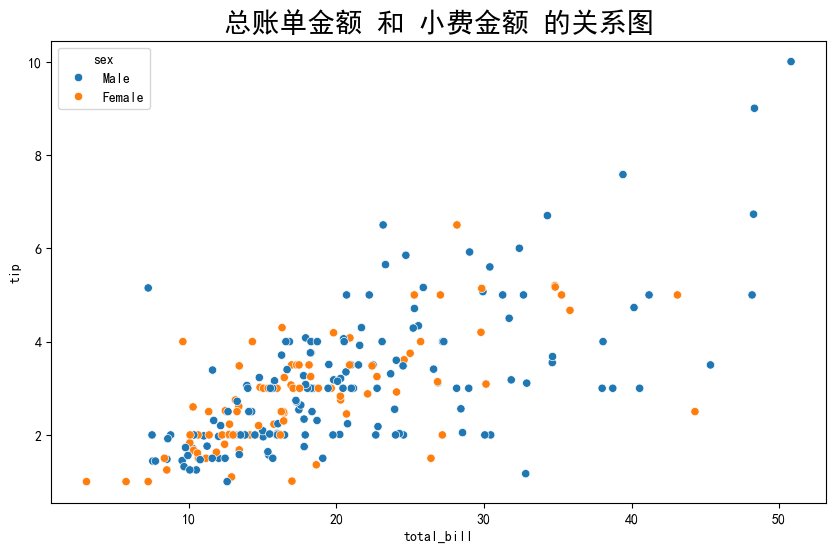

In [92]:
# 需求: 描述 总账单金额 和 小费的分布情况(关系图) -> 散点图
# x轴 -> 总账单金额, y轴 -> 小费金额.
fig, ax = plt.subplots(figsize=(10, 6))
# 参1: 要操作的df对象, x: 总账单金额, y: 小费金额.
sns.scatterplot(data=df, x='total_bill', y='tip', hue='sex')
ax.set_title('总账单金额 和 小费金额 的关系图', fontsize=20)
plt.show()

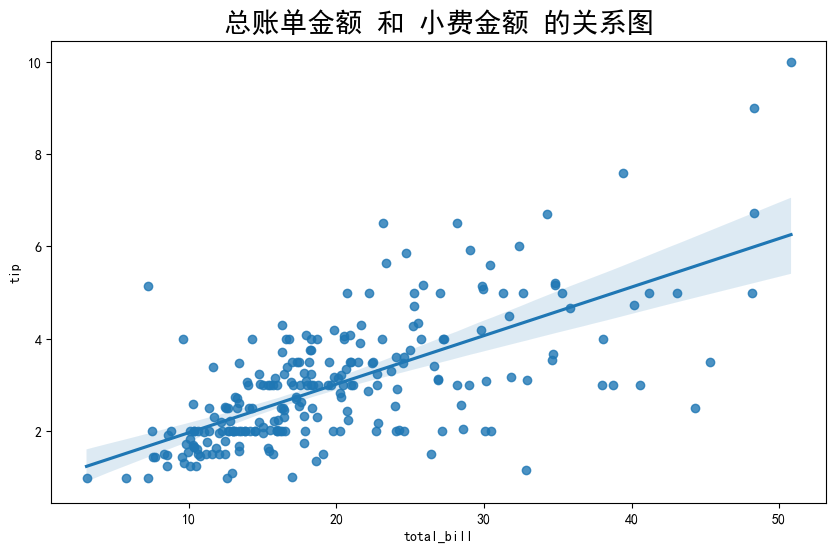

In [95]:
fig, ax = plt.subplots(figsize=(10, 6))
# 参1: 要操作的df对象, x: 总账单金额, y: 小费金额.
sns.regplot(data=df, x='total_bill', y='tip')       # 会绘制1条拟合回归线, 默认是线性回归.
ax.set_title('总账单金额 和 小费金额 的关系图', fontsize=20)
plt.show()

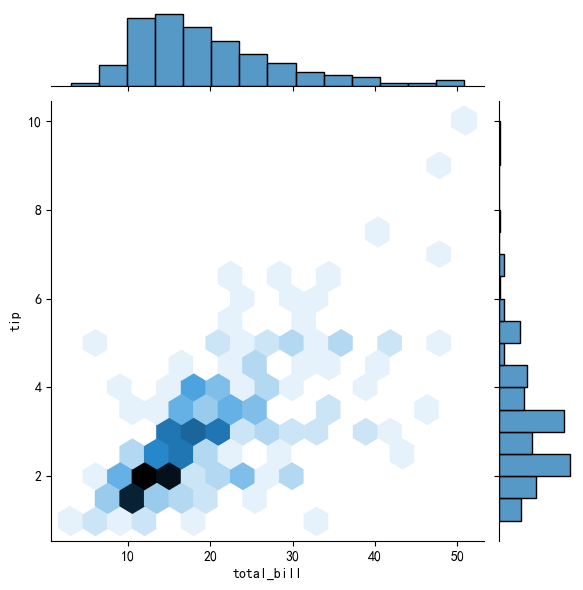

In [100]:
# 参1: 要操作的df对象, x: 总账单金额, y: 小费金额.
# sns.jointplot(data=df, x='total_bill', y='tip', kind='reg')       # 会绘制1条拟合回归线, 默认是线性回归.
sns.jointplot(data=df, x='total_bill', y='tip', kind='hex')         # kind='hex' -> 蜂巢图
ax.set_title('总账单金额 和 小费金额 的关系图', fontsize=20)
plt.show()

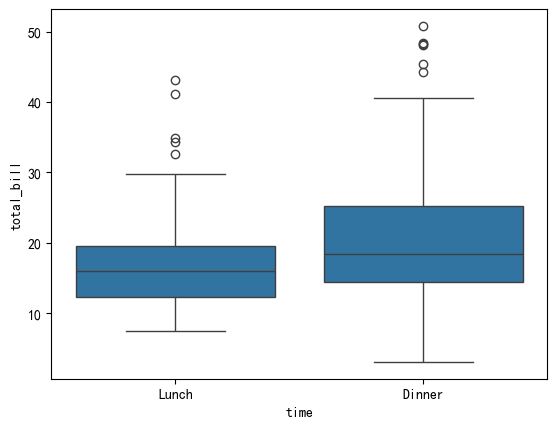

In [102]:
# 参1: 要操作的df对象, x: 时间(午餐, 晚餐), y: 账单总金额.
# 箱线图.
sns.boxplot(data=df, x='time', y='total_bill')         # kind='hex' -> 蜂巢图
plt.show()

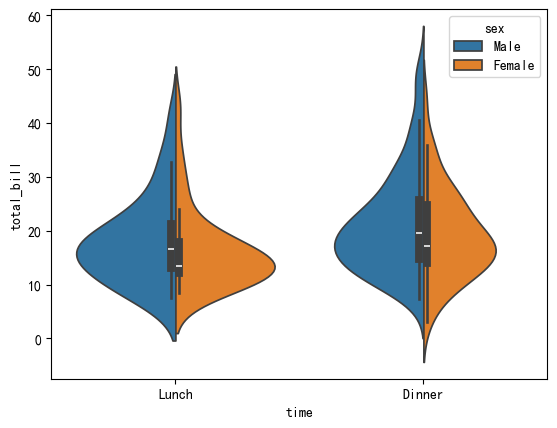

In [105]:
# 参1: 要操作的df对象, x: 时间(午餐, 晚餐), y: 账单总金额.
# 小提琴图.
sns.violinplot(data=df, x='time', y='total_bill', hue='sex', split=True)         # kind='hex' -> 蜂巢图
plt.show()